<a href="https://colab.research.google.com/github/sharmaaviraj/Deep-Learning-Assignment-Reports/blob/main/dl_lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Actual Digit: 5
Image Shape: (28, 28)

Pixel Values:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0  

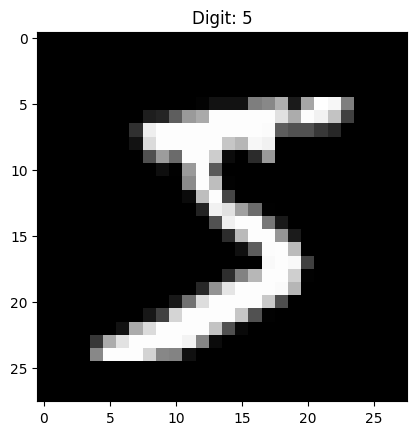

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7545 - loss: 0.9725 - val_accuracy: 0.8957 - val_loss: 0.4556
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8797 - loss: 0.4556 - val_accuracy: 0.9120 - val_loss: 0.3337
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8964 - loss: 0.3767 - val_accuracy: 0.9210 - val_loss: 0.2908
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9047 - loss: 0.3390 - val_accuracy: 0.9240 - val_loss: 0.2653
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9113 - loss: 0.3142 - val_accuracy: 0.9287 - val_loss: 0.2484
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9167 - loss: 0.2954 - val_accuracy: 0.9332 - val_loss: 0.2349
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9217 - loss: 0.2799 - val_accuracy: 0.9387 - val_loss: 0.2233
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9248 - loss: 0.2669 - val_accuracy: 0.

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

image = x_train[0]
label = y_train[0]

print("Actual Digit:", label)
print("Image Shape:", image.shape)

print("\nPixel Values:")
print(image)

plt.imshow(image, cmap='gray')
plt.title(f"Digit: {label}")
plt.show()

x_train = x_train / 255.0
x_test = x_test / 255.0

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

weights, biases = model.layers[1].get_weights()

print("\n========== HIDDEN LAYER ==========")
print("Weight Matrix Shape:", weights.shape)
print("Bias Shape:", biases.shape)

first_neuron_weights = weights[:, 0]
first_neuron_bias = biases[0]

print("\nWeights of First Neuron:")
print(first_neuron_weights)

print("\nBias of First Neuron:")
print(first_neuron_bias)

single_image = x_train[0].reshape(1, 28, 28)
prediction = model.predict(single_image, verbose=0)
predicted_digit = tf.argmax(prediction[0]).numpy()

print("\n========== PREDICTION ==========")
print("Actual Digit:", label)
print("Predicted Digit:", predicted_digit)

print("\nPrediction Probabilities:")
for digit, probability in enumerate(prediction[0]):
    print(f"Digit {digit}: {probability:.4f}")

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("\n========== TEST RESULTS ==========")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)